In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time

from nba_api.stats.endpoints import shotchartdetail

In [ ]:
season = "2023-24"
team_id = 1610612738  # Boston Celtics

shots_response = shotchartdetail.ShotChartDetail(
    team_id=team_id,                # id del equipo
    player_id=0,                    # No quiero un jugador concreto quiero el equipo, por eso pongo 0
    season_nullable=season,         # Quiero esta temporada
    season_type_all_star="Regular Season",  # Solo la temporada regular
    context_measure_simple="FGA",   # FGA significa Field Goal Attempts, es decir, intentos de tiro. Queremos todos los tiros intentados, no solo los anotados
    league_id="00",
    timeout=60                      # Le damos más tiempo a la API para responder
)

shots_df = shots_response.shot_chart_detail.get_data_frame()    # Convertimos la respuesta a un DataFrame de pandas

shots_df["SEASON"] = season

shots_df.head()

,GRID_TYPE,GAME_ID,GAME_EVENT_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_NAME,PERIOD,MINUTES_REMAINING,SECONDS_REMAINING,...,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_ATTEMPTED_FLAG,SHOT_MADE_FLAG,GAME_DATE,HTM,VTM,SEASON
0,Shot Chart Detail,0022300010,7,201950,Jrue Holiday,1610612738,Boston Celtics,1,11,39,...,Less Than 8 ft.,7,16,71,1,1,20231110,BOS,BKN,2023-24
1,Shot Chart Detail,0022300010,11,1627759,Jaylen Brown,1610612738,Boston Celtics,1,11,13,...,Less Than 8 ft.,3,12,35,1,0,20231110,BOS,BKN,2023-24
2,Shot Chart Detail,0022300010,21,1628369,Jayson Tatum,1610612738,Boston Celtics,1,10,27,...,24+ ft.,28,135,248,1,0,20231110,BOS,BKN,2023-24
3,Shot Chart Detail,0022300010,23,1627759,Jaylen Brown,1610612738,Boston Celtics,1,10,22,...,16-24 ft.,18,-134,122,1,1,20231110,BOS,BKN,2023-24
4,Shot Chart Detail,0022300010,30,1627759,Jaylen Brown,1610612738,Boston Celtics,1,10,2,...,24+ ft.,27,-147,227,1,1,20231110,BOS,BKN,2023-24


In [ ]:
shots_df.shape      # Cuantas filas y columnas tiene el DataFrame

(7396, 25)

In [4]:
shots_df.columns

Index(['GRID_TYPE', 'GAME_ID', 'GAME_EVENT_ID', 'PLAYER_ID', 'PLAYER_NAME',
       'TEAM_ID', 'TEAM_NAME', 'PERIOD', 'MINUTES_REMAINING',
       'SECONDS_REMAINING', 'EVENT_TYPE', 'ACTION_TYPE', 'SHOT_TYPE',
       'SHOT_ZONE_BASIC', 'SHOT_ZONE_AREA', 'SHOT_ZONE_RANGE', 'SHOT_DISTANCE',
       'LOC_X', 'LOC_Y', 'SHOT_ATTEMPTED_FLAG', 'SHOT_MADE_FLAG', 'GAME_DATE',
       'HTM', 'VTM', 'SEASON'],
      dtype='str')

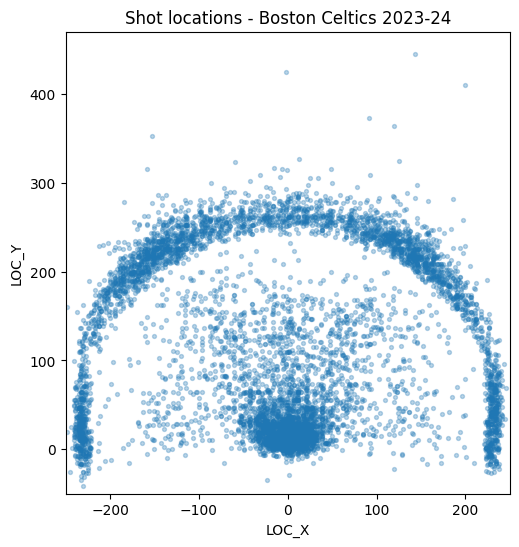

In [5]:
plt.figure(figsize=(6, 6))

plt.scatter(
    shots_df["LOC_X"],
    shots_df["LOC_Y"],
    alpha=0.3,
    s=8
)

plt.title("Shot locations - Boston Celtics 2023-24")
plt.xlabel("LOC_X")
plt.ylabel("LOC_Y")
plt.xlim(-250, 250)
plt.ylim(-50, 470)
plt.gca().set_aspect("equal", adjustable="box")
plt.show()

In [6]:
shots_df.to_csv("../../data/raw/boston_celtics_shots_2023_24.csv", index=False)

In [8]:
shots_df[
    [
        "SEASON",
        "TEAM_NAME",
        "PLAYER_NAME",
        "SHOT_TYPE",
        "SHOT_ZONE_BASIC",
        "SHOT_ZONE_AREA",
        "SHOT_ZONE_RANGE",
        "SHOT_DISTANCE",
        "LOC_X",
        "LOC_Y",
        "SHOT_MADE_FLAG"
    ]
].head(10)

,SEASON,TEAM_NAME,PLAYER_NAME,SHOT_TYPE,SHOT_ZONE_BASIC,SHOT_ZONE_AREA,SHOT_ZONE_RANGE,SHOT_DISTANCE,LOC_X,LOC_Y,SHOT_MADE_FLAG
0,2023-24,Boston Celtics,Jrue Holiday,2PT Field Goal,In The Paint (Non-RA),Center(C),Less Than 8 ft.,7,16,71,1
1,2023-24,Boston Celtics,Jaylen Brown,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,12,35,0
2,2023-24,Boston Celtics,Jayson Tatum,3PT Field Goal,Above the Break 3,Right Side Center(RC),24+ ft.,28,135,248,0
3,2023-24,Boston Celtics,Jaylen Brown,2PT Field Goal,Mid-Range,Left Side Center(LC),16-24 ft.,18,-134,122,1
4,2023-24,Boston Celtics,Jaylen Brown,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,27,-147,227,1
5,2023-24,Boston Celtics,Kristaps Porziņģis,2PT Field Goal,Mid-Range,Left Side(L),8-16 ft.,13,-116,75,1
6,2023-24,Boston Celtics,Jaylen Brown,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,26,-176,197,1
7,2023-24,Boston Celtics,Jaylen Brown,2PT Field Goal,Mid-Range,Right Side Center(RC),16-24 ft.,18,126,135,0
8,2023-24,Boston Celtics,Jrue Holiday,3PT Field Goal,Above the Break 3,Left Side Center(LC),24+ ft.,26,-178,195,1
9,2023-24,Boston Celtics,Jaylen Brown,2PT Field Goal,Restricted Area,Center(C),Less Than 8 ft.,3,6,36,1


## 2. Clasificación de los tiros por zona

In [11]:
def classify_shot(row):
    if row["SHOT_TYPE"] == "3PT Field Goal":
        return "Three"
    elif row["SHOT_DISTANCE"] <= 8:
        return "Rim"
    else:
        return "Mid-range"


shots_df["SHOT_GROUP"] = shots_df.apply(classify_shot, axis=1)

In [12]:
shots_df[
    [
        "PLAYER_NAME",
        "TEAM_NAME",
        "SHOT_TYPE",
        "SHOT_DISTANCE",
        "SHOT_ZONE_BASIC",
        "SHOT_GROUP",
        "SHOT_MADE_FLAG"
    ]
].head(20)

,PLAYER_NAME,TEAM_NAME,SHOT_TYPE,SHOT_DISTANCE,SHOT_ZONE_BASIC,SHOT_GROUP,SHOT_MADE_FLAG
0,Jrue Holiday,Boston Celtics,2PT Field Goal,7,In The Paint (Non-RA),Rim,1
1,Jaylen Brown,Boston Celtics,2PT Field Goal,3,Restricted Area,Rim,0
2,Jayson Tatum,Boston Celtics,3PT Field Goal,28,Above the Break 3,Three,0
3,Jaylen Brown,Boston Celtics,2PT Field Goal,18,Mid-Range,Mid-range,1
4,Jaylen Brown,Boston Celtics,3PT Field Goal,27,Above the Break 3,Three,1
5,Kristaps Porziņģis,Boston Celtics,2PT Field Goal,13,Mid-Range,Mid-range,1
6,Jaylen Brown,Boston Celtics,3PT Field Goal,26,Above the Break 3,Three,1
7,Jaylen Brown,Boston Celtics,2PT Field Goal,18,Mid-Range,Mid-range,0
8,Jrue Holiday,Boston Celtics,3PT Field Goal,26,Above the Break 3,Three,1
9,Jaylen Brown,Boston Celtics,2PT Field Goal,3,Restricted Area,Rim,1


In [13]:
shots_df["SHOT_GROUP"].value_counts()

SHOT_GROUP
Three        3482
Rim          2785
Mid-range    1129
Name: count, dtype: int64

In [14]:
shots_df["SHOT_GROUP"].value_counts(normalize=True) * 100

SHOT_GROUP
Three        47.079502
Rim          37.655489
Mid-range    15.265008
Name: proportion, dtype: float64

In [16]:
# Boston, un equipo moderno y ganador, concentra la mayoría de sus tiros en triple y aro, mientras que la media distancia queda reducida a una proporción mucho menor.

In [17]:
shot_group_summary = (
    shots_df["SHOT_GROUP"]
    .value_counts()
    .reset_index()
)

shot_group_summary.columns = ["SHOT_GROUP", "FGA"]

shot_group_summary["FGA_SHARE"] = (
    shot_group_summary["FGA"] / shot_group_summary["FGA"].sum()
)

shot_group_summary

,SHOT_GROUP,FGA,FGA_SHARE
0,Three,3482,0.470795
1,Rim,2785,0.376555
2,Mid-range,1129,0.152650


In [18]:
shot_group_summary["FGA_SHARE_PCT"] = (
    shot_group_summary["FGA_SHARE"] * 100
).round(2)

shot_group_summary

,SHOT_GROUP,FGA,FGA_SHARE,FGA_SHARE_PCT
0,Three,3482,0.470795,47.08
1,Rim,2785,0.376555,37.66
2,Mid-range,1129,0.152650,15.27


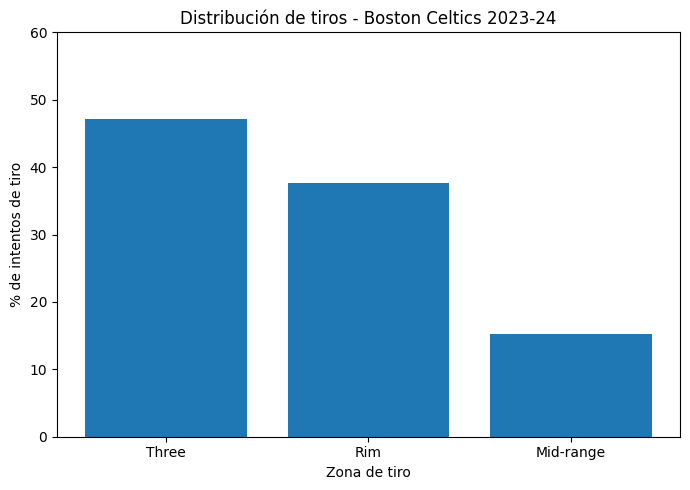

In [19]:
plt.figure(figsize=(7, 5))

plt.bar(
    shot_group_summary["SHOT_GROUP"],
    shot_group_summary["FGA_SHARE_PCT"]
)

plt.title("Distribución de tiros - Boston Celtics 2023-24")
plt.xlabel("Zona de tiro")
plt.ylabel("% de intentos de tiro")
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

In [ ]:
import os

os.makedirs("../../data/processed/carlos", exist_ok=True)

shots_df.to_csv(
    "../../data/processed/carlos/boston_celtics_shots_2023_24_with_groups.csv",
    index=False
)

shot_group_summary.to_csv(
    "../../data/processed/carlos/boston_celtics_shot_group_summary_2023_24.csv",
    index=False
)